# 🧠 Model & Training
**Fashion Compatibility Project | Deep Learning Course**

### What you'll do:
- Load the data pipeline (Swin-T and ConvNeXt-T backbones)
- Implement triplet loss and contrastive loss
- Run all 4 experiments and save checkpoints to Google Drive

### The 4 experiments:
| Run | Backbone | Loss |
|-----|----------|------|
| 1 | ConvNeXt-T | Triplet |
| 2 | ConvNeXt-T | Contrastive |
| 3 | Swin-T | Triplet |
| 4 | Swin-T | Contrastive |

---
⚠️ **Before running:** `Runtime → Change runtime type → T4 GPU → Save`

## Cell 1 — Install dependencies

In [1]:
!pip install -q datasets torch torchvision Pillow numpy pandas matplotlib tqdm
print('✅ Done.')

✅ Done.


## Cell 2 — Check GPU

In [2]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('⚠️  No GPU! Go to Runtime → Change runtime type → T4 GPU')

Device: cuda
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Memory: 102.0 GB


In [3]:
import torch, gc
torch.cuda.empty_cache()
gc.collect()

96

## Cell 3 — Load dataset and build DataLoaders
This is the same pipeline as Sandra's notebook, kept here so this notebook is self-contained.

In [4]:
import random
import numpy as np
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from collections import defaultdict

# ── Load dataset ──────────────────────────────────────────
print('Loading Marqo/polyvore...')
dataset = load_dataset('Marqo/polyvore')
# Only split is called 'data'
all_data = dataset['data']
total    = len(all_data)          # 94096
split_at = int(total * 0.9)
train_hf = all_data.select(range(0, split_at))
val_hf   = all_data.select(range(split_at, total))
print(f'Total: {total} | Train: {len(train_hf)} | Val: {len(val_hf)}')

# ── Transforms ────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# ── Dataset class ─────────────────────────────────────────
class PolyvoreDataset(Dataset):
    """
    outfit_id is extracted from item_ID: '100002074_1' → '100002074'
    Returns (anchor, positive, negative) triplets.
    """
    def __init__(self, hf_split, transform=None):
        self.data      = hf_split
        self.transform = transform
        self.outfit_to_idx = defaultdict(list)
        for i in range(len(hf_split)):
            oid = hf_split[i]['item_ID'].rsplit('_', 1)[0]
            self.outfit_to_idx[oid].append(i)
        self.valid_outfits  = [o for o, idxs in self.outfit_to_idx.items() if len(idxs) >= 2]
        self.all_outfit_ids = list(self.outfit_to_idx.keys())

    def __len__(self): return len(self.valid_outfits)

    def _load(self, i):
        img = self.data[i]['image'].convert('RGB')
        return self.transform(img) if self.transform else img

    def __getitem__(self, idx):
        oid = self.valid_outfits[idx]
        a, p = random.sample(self.outfit_to_idx[oid], 2)
        neg_oid = random.choice([o for o in self.all_outfit_ids if o != oid])
        n = random.choice(self.outfit_to_idx[neg_oid])
        return self._load(a), self._load(p), self._load(n)

# ── Build loaders ─────────────────────────────────────────
BATCH_SIZE = 16 # ← changed from 64 to 16
train_dataset = PolyvoreDataset(train_hf, train_transform)
val_dataset   = PolyvoreDataset(val_hf,   val_transform)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'\n✅ DataLoaders ready | Train: {len(train_loader)} batches | Val: {len(val_loader)} batches')

Loading Marqo/polyvore...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/data-00000-of-00006.parquet:   0%|          | 0.00/428M [00:00<?, ?B/s]

data/data-00001-of-00006.parquet:   0%|          | 0.00/421M [00:00<?, ?B/s]

...

data/data-00003-of-00006.parquet:   0%|          | 0.00/416M [00:00<?, ?B/s]

data/data-00004-of-00006.parquet:   0%|          | 0.00/422M [00:00<?, ?B/s]

data/data-00005-of-00006.parquet:   0%|          | 0.00/409M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/94096 [00:00<?, ? examples/s]

Total: 94096 | Train: 84686 | Val: 9410

✅ DataLoaders ready | Train: 1157 batches | Val: 133 batches


## Cell 4 — Model: FashionEncoder (backbone + projection head)

In [5]:
import torch.nn as nn
import torchvision.models as models


class FashionEncoder(nn.Module):
    """
    Pretrained backbone (Swin-T or ConvNeXt-T) + 2-layer MLP projection head.
    Outputs L2-normalized embeddings of size `embed_dim`.
    """

    def __init__(self, backbone_name='convnext_tiny', embed_dim=128):
        super().__init__()

        if backbone_name == 'convnext_tiny':
            base        = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
            in_features = base.classifier[2].in_features   # 768
            base.classifier = nn.Identity()

        elif backbone_name == 'swin_t':
            base        = models.swin_t(weights=models.Swin_T_Weights.IMAGENET1K_V1)
            in_features = base.head.in_features             # 768
            base.head   = nn.Identity()

        else:
            raise ValueError(f'Unknown backbone: {backbone_name}. Use "convnext_tiny" or "swin_t"')

        self.backbone  = base
        self.projector = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Linear(256, embed_dim)
        )

    def forward(self, x):
        feat = self.backbone(x)
        # ConvNeXt returns [B, C, 1, 1] after global pooling — flatten
        if feat.dim() > 2:
            feat = feat.flatten(1)
        emb = self.projector(feat)
        return nn.functional.normalize(emb, p=2, dim=1)   # L2 normalize


# Quick test: both backbones
dummy = torch.randn(2, 3, 224, 224)
for name in ['convnext_tiny', 'swin_t']:
    m   = FashionEncoder(name, embed_dim=128)
    out = m(dummy)
    print(f'{name}: output {out.shape} | norms: {out.norm(dim=1).tolist()}')

print('\n✅ Both backbones work!')

Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 294MB/s] 


convnext_tiny: output torch.Size([2, 128]) | norms: [1.0, 0.9999999403953552]
Downloading: "https://download.pytorch.org/models/swin_t-704ceda3.pth" to /root/.cache/torch/hub/checkpoints/swin_t-704ceda3.pth


100%|██████████| 108M/108M [00:00<00:00, 249MB/s]


swin_t: output torch.Size([2, 128]) | norms: [0.9999999403953552, 0.9999999403953552]

✅ Both backbones work!


## Cell 5 — Loss functions: Triplet and Contrastive

In [6]:
import torch.nn.functional as F


def triplet_loss(anchor, positive, negative, margin=0.3):
    """
    Triplet Margin Loss.
    L = max(0, d(a,p) - d(a,n) + margin)
    Pulls anchor-positive together, pushes anchor-negative apart.
    """
    d_pos = F.pairwise_distance(anchor, positive)
    d_neg = F.pairwise_distance(anchor, negative)
    return F.relu(d_pos - d_neg + margin).mean()


def contrastive_loss(anchor, positive, negative, margin=1.0):
    """
    Contrastive Loss.
    Compatible pairs (anchor-positive) → minimize distance.
    Incompatible pairs (anchor-negative) → push beyond margin.
    """
    d_pos = F.pairwise_distance(anchor, positive)
    d_neg = F.pairwise_distance(anchor, negative)
    return (d_pos.pow(2) + F.relu(margin - d_neg).pow(2)).mean()


# Quick test
a = F.normalize(torch.randn(4, 128), dim=1)
p = F.normalize(torch.randn(4, 128), dim=1)
n = F.normalize(torch.randn(4, 128), dim=1)
print(f'Triplet loss:     {triplet_loss(a, p, n).item():.4f}')
print(f'Contrastive loss: {contrastive_loss(a, p, n).item():.4f}')
print('✅ Loss functions work!')

Triplet loss:     0.3317
Contrastive loss: 2.0593
✅ Loss functions work!


## Cell 6 — Training and validation loop functions

In [7]:
from tqdm import tqdm


def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    total = 0.0
    for a, p, n in tqdm(loader, desc='  Train', leave=False):
        a, p, n = a.to(device), p.to(device), n.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(a), model(p), model(n))
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / len(loader)


def validate(model, loader, loss_fn, device):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for a, p, n in tqdm(loader, desc='  Val  ', leave=False):
            a, p, n = a.to(device), p.to(device), n.to(device)
            total += loss_fn(model(a), model(p), model(n)).item()
    return total / len(loader)


print('✅ Training loop functions defined.')

✅ Training loop functions defined.


## Cell 7 — Mount Google Drive (to save checkpoints safely)

In [9]:
import os
from google.colab import drive

drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/DL_Project_Checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f'✅ Checkpoints will be saved to: {SAVE_DIR}')

Mounted at /content/drive
✅ Checkpoints will be saved to: /content/drive/MyDrive/DL_Project_Checkpoints


## Cell 8 — ⚙️ RUN AN EXPERIMENT

**Change only the first 2 lines to switch between the 4 runs:**

| Run | BACKBONE | LOSS_FN |
|-----|----------|---------|
| 1 ✅ | `'convnext_tiny'` | `'triplet'` |
| 2   | `'convnext_tiny'` | `'contrastive'` |
| 3   | `'swin_t'` | `'triplet'` |
| 4   | `'swin_t'` | `'contrastive'` |

In [10]:
import os, gc
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'
torch.cuda.empty_cache()
gc.collect()

# ── CONFIG — only change these two lines between runs ──────
BACKBONE = 'convnext_tiny'   # 'convnext_tiny' or 'swin_t'
LOSS_FN  = 'triplet'         # 'triplet' or 'contrastive'
# ───────────────────────────────────────────────────────────
EMBED_DIM  = 128
MAX_EPOCHS = 30
PATIENCE   = 5
LR_HEAD    = 1e-4
LR_BACK    = 1e-5

RUN_NAME = f'{BACKBONE}__{LOSS_FN}'
loss_fn  = triplet_loss if LOSS_FN == 'triplet' else contrastive_loss

# Build model
model = FashionEncoder(BACKBONE, embed_dim=EMBED_DIM).to(device)

# ── Phase 1: freeze backbone, train only projection head ──
for p in model.backbone.parameters():
    p.requires_grad = False

optimizer = torch.optim.AdamW(
    model.projector.parameters(), lr=LR_HEAD, weight_decay=1e-4
)

print('Phase 1: training projection head only (3 warmup epochs)...\n')
for epoch in range(1, 4):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    val_loss   = validate(model, val_loader, loss_fn, device)
    print(f'  Warmup {epoch}/3  train={train_loss:.4f}  val={val_loss:.4f}')

# ── Phase 2: unfreeze backbone, fine-tune everything ──────
print('\nPhase 2: unfreezing backbone for full fine-tuning...\n')
for p in model.backbone.parameters():
    p.requires_grad = True

optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(),  'lr': LR_BACK},
    {'params': model.projector.parameters(), 'lr': LR_HEAD}
], weight_decay=1e-4)

print(f'🚀 Starting run: {RUN_NAME}')
print(f'   Backbone: {BACKBONE} | Loss: {LOSS_FN} | Embed: {EMBED_DIM}d')
print(f'   Max epochs: {MAX_EPOCHS} | Patience: {PATIENCE}\n')

best_val   = float('inf')
no_improve = 0
train_losses, val_losses = [], []

for epoch in range(1, MAX_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, device)
    val_loss   = validate(model, val_loader, loss_fn, device)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'Epoch {epoch:02d}/{MAX_EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}', end='')

    if val_loss < best_val:
        best_val   = val_loss
        no_improve = 0
        ckpt = os.path.join(SAVE_DIR, f'{RUN_NAME}__best.pt')
        torch.save(model.state_dict(), ckpt)
        print(f'  💾 saved')
    else:
        no_improve += 1
        print(f'  (no improve {no_improve}/{PATIENCE})')
        if no_improve >= PATIENCE:
            print(f'\n⏹️  Early stopping.')
            break

print(f'\n✅ Run done: {RUN_NAME}  |  Best val loss: {best_val:.4f}')

Phase 1: training projection head only (3 warmup epochs)...



  Warmup 1/3  train=0.2721  val=0.2493


  Warmup 2/3  train=0.2478  val=0.2351


  Warmup 3/3  train=0.2391  val=0.2411

Phase 2: unfreezing backbone for full fine-tuning...

🚀 Starting run: convnext_tiny__triplet
   Backbone: convnext_tiny | Loss: triplet | Embed: 128d
   Max epochs: 30 | Patience: 5



Epoch 01/30  train=0.2311  val=0.2233  💾 saved


...

Epoch 14/30  train=0.1751  val=0.2099  (no improve 1/5)


Epoch 15/30  train=0.1737  val=0.2098  (no improve 2/5)


Epoch 16/30  train=0.1719  val=0.2010  (no improve 3/5)


Epoch 17/30  train=0.1696  val=0.2030  (no improve 4/5)


Epoch 18/30  train=0.1667  val=0.2075  (no improve 5/5)

⏹️  Early stopping.

✅ Run done: convnext_tiny__triplet  |  Best val loss: 0.1974


## Cell 9 — Plot training curves

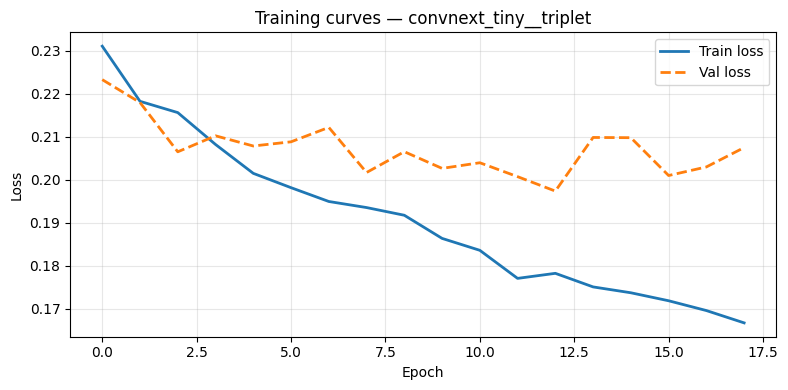

✅ Saved to /content/drive/MyDrive/DL_Project_Checkpoints/convnext_tiny__triplet__curves.png


In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train loss', linewidth=2)
plt.plot(val_losses,   label='Val loss',   linewidth=2, linestyle='--')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training curves — {RUN_NAME}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
curve_path = os.path.join(SAVE_DIR, f'{RUN_NAME}__curves.png')
plt.savefig(curve_path, dpi=120)
plt.show()
print(f'✅ Saved to {curve_path}')

## Cell 10 — Results tracker (fill after each run)

In [12]:
# Fill in best val loss after completing each run
results = {
    'convnext_tiny__triplet':     None,   # ← fill after run 1
    'convnext_tiny__contrastive': None,   # ← fill after run 2
    'swin_t__triplet':            None,   # ← fill after run 3
    'swin_t__contrastive':        None,   # ← fill after run 4
}

print('Results so far:')
print('-' * 45)
for run, val in results.items():
    status = f'{val:.4f}' if val is not None else 'pending...'
    print(f'  {run:<35} {status}')
print('-' * 45)

Results so far:
---------------------------------------------
  convnext_tiny__triplet              pending...
  convnext_tiny__contrastive          pending...
  swin_t__triplet                     pending...
  swin_t__contrastive                 pending...
---------------------------------------------
